# CINF104 - Proyecto 1: Predicción GRD Hospital El Pino
## 01 - Análisis Exploratorio de Datos (EDA)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga de datos

In [6]:
df = pd.read_csv('../data/dataset_elpino.csv', sep=None, engine='python')
print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
df.head()

Filas: 14,561
Columnas: 68


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada, en enfermedades clasificadas ...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] como causa de enfermedades cla...,L89.9 - Úlcera de decúbito y area de presión no especificadas,"L08.9 - Infección local de la piel y del tejido subcutáneo, no especificada",B96.2 - Escherichia coli [E. coli] como causa de enfermedades clasificadas e...,A41.5 - Sepsis por otros organnismos Gram negativos,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga, no especificada",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamiento debidos al uso de múltiples...,"F10.2 - Trastornos mentales y del comportamiento debidos al uso de alcohol, ...","E46 - Desnutrición proteicocalórica, no especificada","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEMADURA NO ESCISIONAL",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROFILACTICA.OTRA,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.

## 2. Estructura del dataset

In [7]:
# Separar columnas por tipo
diag_cols = [c for c in df.columns if 'Diag' in c]
proced_cols = [c for c in df.columns if 'Proced' in c]

print(f'Columnas de diagnóstico: {len(diag_cols)}')
print(f'Columnas de procedimiento: {len(proced_cols)}')
print(f'Otras columnas: Edad, Sexo, GRD')

Columnas de diagnóstico: 35
Columnas de procedimiento: 30
Otras columnas: Edad, Sexo, GRD


## 3. Calidad de datos - Valores nulos

In [8]:
# Nulos en columnas clave
key_cols = ['Diag 01 Principal (cod+des)', 'Edad en años', 'Sexo (Desc)', 'GRD']
print('Nulos en columnas clave:')
print(df[key_cols].isna().sum())
print()

# Nulos por diagnóstico secundario
nulos_diag = df[diag_cols].isna().sum()
print('Completitud diagnósticos secundarios:')
for col, n in nulos_diag.items():
    pct_lleno = (1 - n/len(df)) * 100
    print(f'  {col[:30]}: {pct_lleno:.1f}% con datos')

Nulos en columnas clave:
Diag 01 Principal (cod+des)    0
Edad en años                   0
Sexo (Desc)                    0
GRD                            0
dtype: int64

Completitud diagnósticos secundarios:
  Diag 01 Principal (cod+des): 100.0% con datos
  Diag 02 Secundario (cod+des): 100.0% con datos
  Diag 03 Secundario (cod+des): 100.0% con datos
  Diag 04 Secundario (cod+des): 100.0% con datos
  Diag 05 Secundario (cod+des): 100.0% con datos
  Diag 06 Secundario (cod+des): 100.0% con datos
  Diag 07 Secundario (cod+des): 100.0% con datos
  Diag 08 Secundario (cod+des): 100.0% con datos
  Diag 09 Secundario (cod+des): 100.0% con datos
  Diag 10 Secundario (cod+des): 100.0% con datos
  Diag 11 Secundario (cod+des): 100.0% con datos
  Diag 12 Secundario (cod+des): 100.0% con datos
  Diag 13 Secundario (cod+des): 100.0% con datos
  Diag 14 Secundario (cod+des): 100.0% con datos
  Diag 15 Secundario (cod+des): 100.0% con datos
  Diag 16 Secundario (cod+des): 100.0% con datos
  Diag 1

## 4. Variable objetivo: GRD

In [9]:
print(f'Clases únicas de GRD: {df["GRD"].nunique()}')
print()
print('Top 15 GRDs más frecuentes:')
top_grd = df['GRD'].value_counts().head(15)
print(top_grd)

Clases únicas de GRD: 526

Top 15 GRDs más frecuentes:
GRD
146101 - PH CESÁREA                                                                            813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO         639
146131 - PH PARTO VAGINAL                                                                      538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                            389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                           325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA                                                      317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC                                    287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE                                                      252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC                            248
146102 - PH CESÁREA W/CC                          

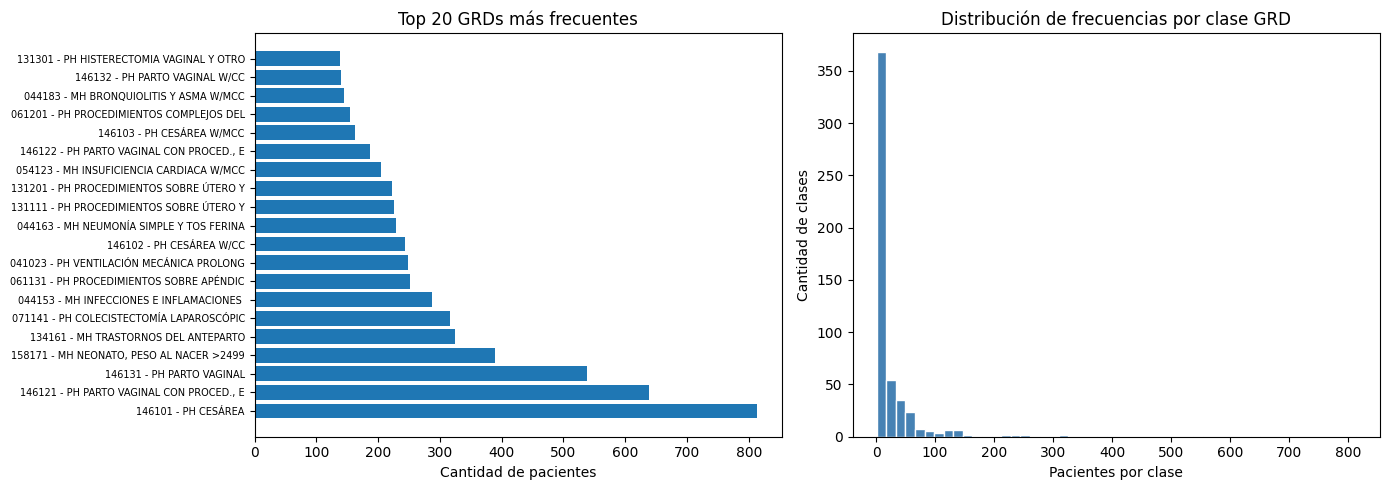

In [10]:
# Distribución de frecuencias por clase
conteos = df['GRD'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 clases
top20 = conteos.head(20)
axes[0].barh(range(len(top20)), top20.values)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels([g[:40] for g in top20.index], fontsize=7)
axes[0].set_title('Top 20 GRDs más frecuentes')
axes[0].set_xlabel('Cantidad de pacientes')

# Distribución de frecuencias
axes[1].hist(conteos.values, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de frecuencias por clase GRD')
axes[1].set_xlabel('Pacientes por clase')
axes[1].set_ylabel('Cantidad de clases')

plt.tight_layout()
plt.savefig('../reports/grd_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Variables demográficas

In [11]:
print('Distribución de Edad:')
print(df['Edad en años'].describe())
print()
print('Distribución de Sexo:')
print(df['Sexo (Desc)'].value_counts())

Distribución de Edad:
count    14561.000000
mean        39.426550
std         24.681545
min          0.000000
25%         23.000000
50%         36.000000
75%         60.000000
max        121.000000
Name: Edad en años, dtype: float64

Distribución de Sexo:
Sexo (Desc)
Mujer     9617
Hombre    4944
Name: count, dtype: int64


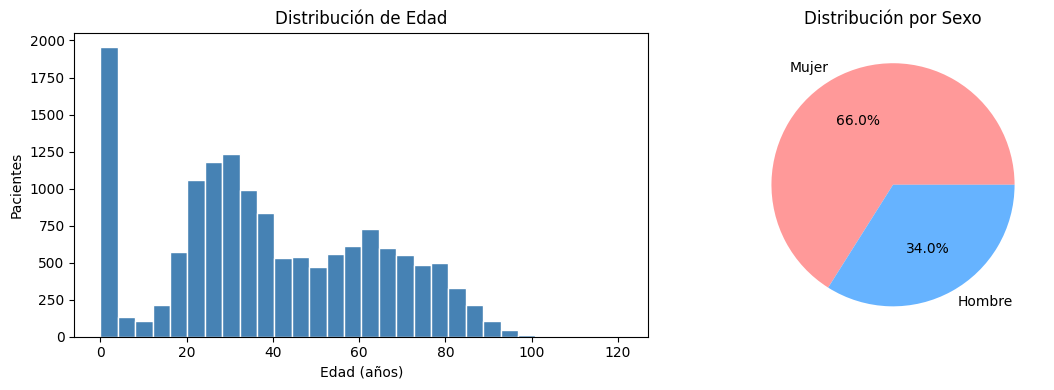

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma edad
axes[0].hist(df['Edad en años'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Pacientes')

# Pie chart sexo
sexo_counts = df['Sexo (Desc)'].value_counts()
axes[1].pie(sexo_counts.values, labels=sexo_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Distribución por Sexo')

plt.tight_layout()
plt.savefig('../reports/demograficos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Diagnósticos: cuántos por paciente

In [13]:
# Contar diagnósticos no nulos por fila
df['n_diagnosticos'] = df[diag_cols].notna().sum(axis=1)
df['n_procedimientos'] = df[proced_cols].notna().sum(axis=1)

print('Diagnósticos por paciente:')
print(df['n_diagnosticos'].describe())
print()
print('Procedimientos por paciente:')
print(df['n_procedimientos'].describe())

Diagnósticos por paciente:
count    14561.0
mean        35.0
std          0.0
min         35.0
25%         35.0
50%         35.0
75%         35.0
max         35.0
Name: n_diagnosticos, dtype: float64

Procedimientos por paciente:
count    14561.0
mean        30.0
std          0.0
min         30.0
25%         30.0
50%         30.0
75%         30.0
max         30.0
Name: n_procedimientos, dtype: float64


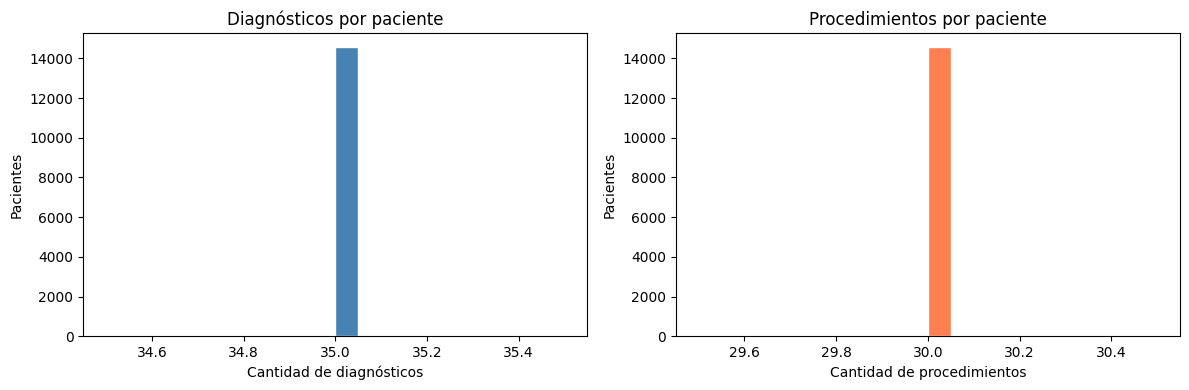

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['n_diagnosticos'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Diagnósticos por paciente')
axes[0].set_xlabel('Cantidad de diagnósticos')
axes[0].set_ylabel('Pacientes')

axes[1].hist(df['n_procedimientos'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Procedimientos por paciente')
axes[1].set_xlabel('Cantidad de procedimientos')
axes[1].set_ylabel('Pacientes')

plt.tight_layout()
plt.savefig('../reports/diag_proced_por_paciente.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Extracción de códigos CIE

In [15]:
# Los diagnósticos vienen como "A41.8 - Descripción"
# Extraemos solo el código antes del " - "
def extraer_codigo(texto):
    if pd.isna(texto):
        return None
    return texto.split(' - ')[0].strip()

# Ejemplo
print('Ejemplo original:', df['Diag 01 Principal (cod+des)'].iloc[0])
print('Código extraído:', extraer_codigo(df['Diag 01 Principal (cod+des)'].iloc[0]))

Ejemplo original: A41.8 - Otras septicemias especificadas
Código extraído: A41.8


In [16]:
# Top diagnósticos principales más frecuentes
df['codigo_diag_principal'] = df['Diag 01 Principal (cod+des)'].apply(extraer_codigo)

print('Top 15 diagnósticos principales:')
print(df['codigo_diag_principal'].value_counts().head(15))

Top 15 diagnósticos principales:
codigo_diag_principal
O70.0    779
O80.0    471
U07.1    327
O34.2    304
E11.5    215
K35.8    208
N10      189
K80.2    184
N39.0    180
I63.8    166
I50.0    162
Z76.2    160
J44.1    137
O24.4    133
K92.2    130
Name: count, dtype: int64
